<a href="https://colab.research.google.com/github/MidhulaMS/EV-Population-Prediction/blob/midhula/EV_Population_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For evaluating Mode
from statistics import mode

# Mutual Information: Target is salary which is continous
from sklearn.feature_selection import mutual_info_regression

# For min max scaling
from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Reading Data

In [ ]:
filepath = "/content/drive/MyDrive/AI ML/Data/washington_EV.csv"

In [ ]:
EV_df = pd.read_csv(filepath)

## Exploratory data analysis (EDA)


In [ ]:
EV_df.head(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,YV4H60PE7S,Kitsap,Bremerton,WA,98310.0,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,277607004,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
1,5YJ3E1EB3K,Snohomish,Lynnwood,WA,98087.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,21.0,478641796,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10
2,1FADP5CUXD,Kitsap,Port Orchard,WA,98367.0,2013,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,35.0,253249678,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
3,5YJSA1H20E,Thurston,Yelm,WA,98597.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,2.0,131872905,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,7SAYGDEE2P,Snohomish,Bothell,WA,98012.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,1.0,260935657,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC,5.306105e+10


In [ ]:
EV_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287763 entries, 0 to 287762
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         287763 non-null  object 
 1   County                                             287754 non-null  object 
 2   City                                               287754 non-null  object 
 3   State                                              287763 non-null  object 
 4   Postal Code                                        287754 non-null  float64
 5   Model Year                                         287763 non-null  int64  
 6   Make                                               287763 non-null  object 
 7   Model                                              287763 non-null  object 
 8   Electric Vehicle Type                              287763 non-null  object

### finding missing values

In [ ]:
#
EV_df.isna().sum()

,0
VIN (1-10),0
County,9
City,9
State,0
Postal Code,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


### finding duplicates

In [ ]:
EV_df.duplicated().sum()

np.int64(0)

### Data Description

In [ ]:
EV_df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,287754.000000,287763.000000,287754.000000,287023.000000,2.877630e+05,2.877540e+05
mean,98174.889729,2022.207299,37.828697,28.849608,2.486886e+08,5.296750e+10
std,2638.364484,3.075325,77.223589,14.889125,6.293818e+07,1.691737e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.258425e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.658514e+08,5.303303e+10
75%,98387.000000,2024.000000,32.000000,42.000000,2.820231e+08,5.305394e+10
max,99801.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


# Data preprocessing

##UNIVARIATE ANALYSIS :used to clean data, catch anomalies, and determine if features require scaling or transformation prior to modeling

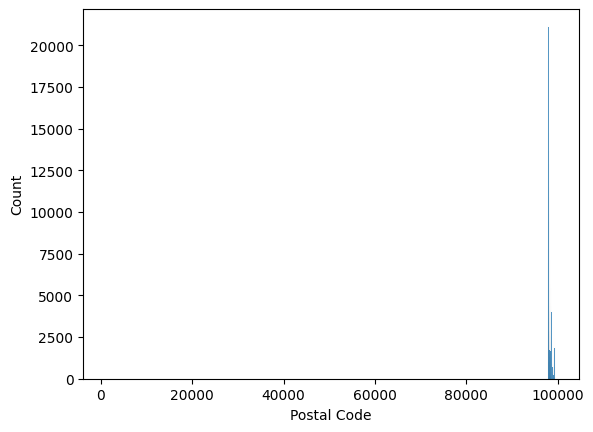

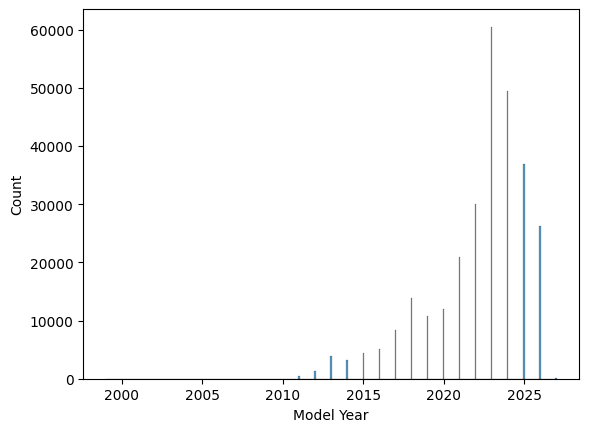

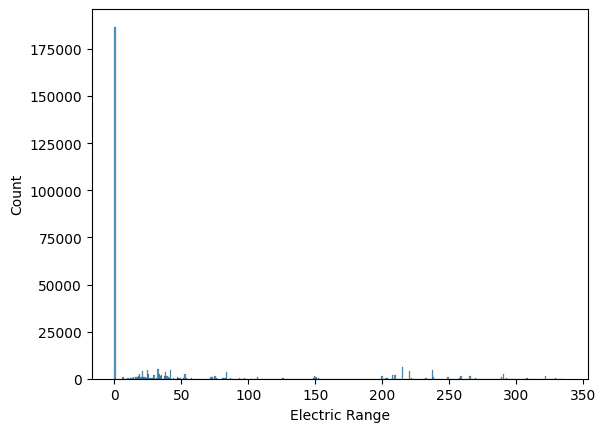

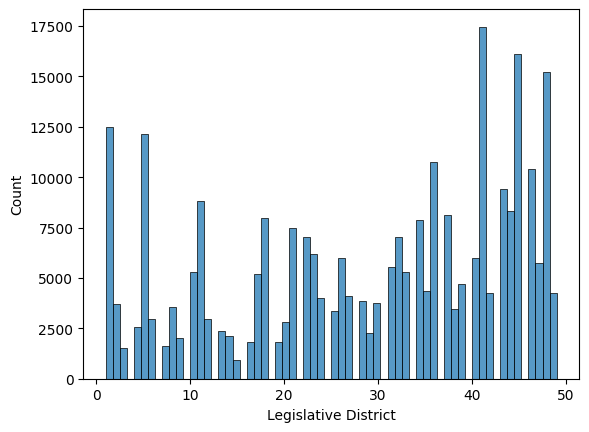

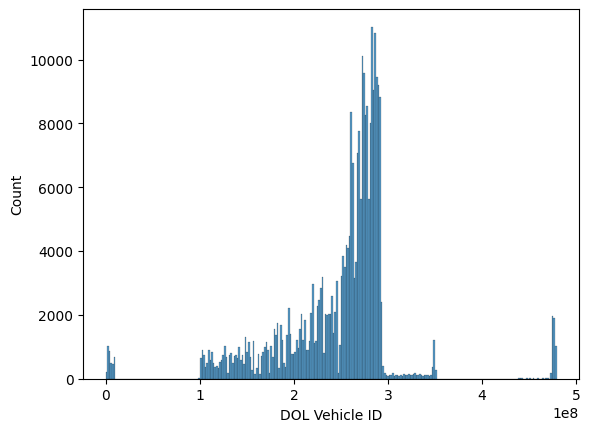

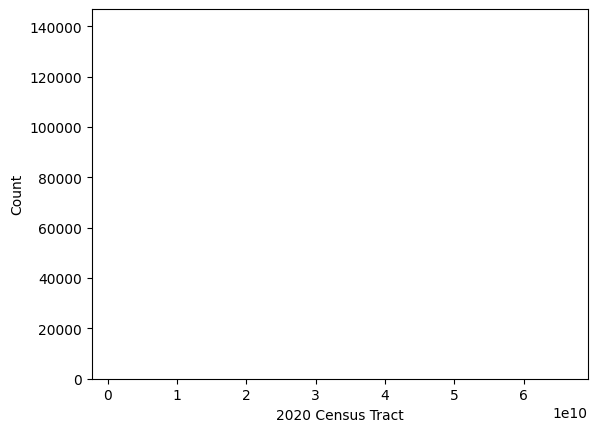

In [ ]:
for cols in EV_df.select_dtypes(include="number"):
  sns.histplot(EV_df[cols])
  plt.show()

## Data Cleaning

In [ ]:
# finding number of unique values in each column
for cols in EV_df :
  print(f"{cols},{EV_df[cols].nunique()},")

VIN (1-10),17690,
County,256,
City,931,
State,53,
Postal Code,1166,
Model Year,23,
Make,48,
Model,196,
Electric Vehicle Type,2,
Clean Alternative Fuel Vehicle (CAFV) Eligibility,3,
Electric Range,115,
Legislative District,49,
DOL Vehicle ID,287763,
Vehicle Location,1165,
Electric Utility,77,
2020 Census Tract,2429,


In [ ]:
EV_df["State"].value_counts()

,count
State,
WA,287024
CA,184
VA,91
MD,47
FL,46
TX,36
CO,25
OR,24
NV,23


### Droping the Irrelevant columns

In [ ]:
# Columns to drop and why:
# - State: almost all the registration is 'WA'
# - DOL Vehicle ID
# - VIN (1-10): redundant with Make/Model
# - 2020 Census Tract:  redundant with County/Postal Code

cols_to_drop = ['State', 'DOL Vehicle ID', 'VIN (1-10)', '2020 Census Tract']

EV_df = EV_df.drop(columns=cols_to_drop)

EV_df.shape

(287763, 12)

### Missing Value Handling

In [ ]:
EV_df.isnull().sum()  #Check missing values

,0
County,9
City,9
Postal Code,9
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0
Electric Range,9
Legislative District,740


In [ ]:
# dropping the null values
cols_tiny_missing = ['County', 'City', 'Postal Code', 'Vehicle Location', 'Electric Utility', 'Electric Range']
print("shape before dropping rows:",EV_df.shape)
EV_df = EV_df.dropna(subset=cols_tiny_missing)

print("Shape after dropping rows:", EV_df.shape)

shape before dropping rows: (287763, 12)
Shape after dropping rows: (287738, 12)


In [ ]:
# filling the cateogrical null value
mode_value = EV_df['Legislative District'].mode()[0]
EV_df['Legislative District'] = EV_df['Legislative District'].fillna(mode_value)


In [ ]:
EV_df.isnull().sum()

,0
County,0
City,0
Postal Code,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0
Electric Range,0
Legislative District,0


## Outlier Handling

In [ ]:
EV_df.info() #checking which are the numerical columns

<class 'pandas.core.frame.DataFrame'>
Index: 287738 entries, 0 to 287762
Data columns (total 12 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   County                                             287738 non-null  object 
 1   City                                               287738 non-null  object 
 2   Postal Code                                        287738 non-null  float64
 3   Model Year                                         287738 non-null  int64  
 4   Make                                               287738 non-null  object 
 5   Model                                              287738 non-null  object 
 6   Electric Vehicle Type                              287738 non-null  object 
 7   Clean Alternative Fuel Vehicle (CAFV) Eligibility  287738 non-null  object 
 8   Electric Range                                     287738 non-null  float64
 9 

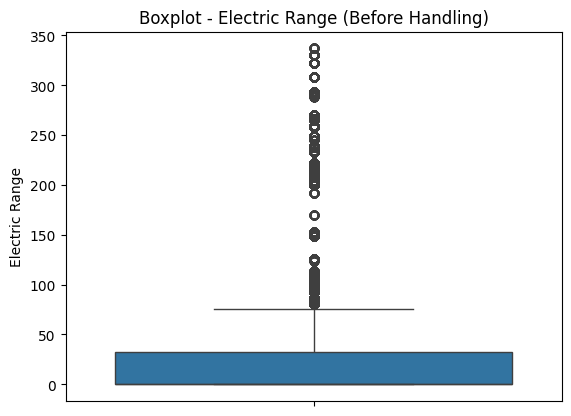

In [ ]:
# now the only numerical column left is Electric Range
sns.boxplot(EV_df['Electric Range'])
plt.title('Boxplot - Electric Range (Before Handling)')
plt.show()

In [ ]:
# Using the IQR method
Q1 = EV_df['Electric Range'].quantile(0.25)
Q3 = EV_df['Electric Range'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Q1: 0.0, Q3: 32.0, IQR: 32.0
Lower bound: -48.0, Upper bound: 80.0


In [ ]:
outliers = EV_df[
    (EV_df['Electric Range'] < lower_bound) |
    (EV_df['Electric Range'] > upper_bound)
]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 43092


In [ ]:
EV_df['Electric Range'] = EV_df['Electric Range'].clip(
    lower=lower_bound, upper=upper_bound)

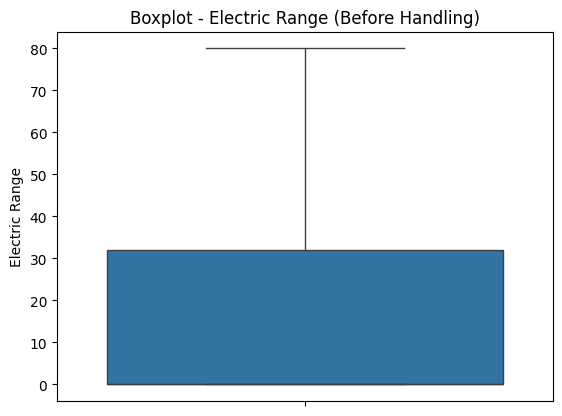

In [ ]:
# Checking whether the Outliers were clipped
sns.boxplot(EV_df['Electric Range'])
plt.title('Boxplot - Electric Range (Before Handling)')
plt.show()

# Data Transformation

## Scaling

In [ ]:
# Numerical columns
num_cols = EV_df.select_dtypes(include = ['int64', 'float64']).columns
num_cols

In [ ]:
# Categorical Columns
cat_cols = EV_df.select_dtypes(include = ['object']).columns
cat_cols

### Min-Max Scaling : Scaling technique that transforms data into a fixed range, usually 0 to 1.

In [ ]:
skewed_cols =['Model Year']

In [ ]:
# Before min max scaling
EV_df.head(2)

In [ ]:
# object for min-max scaling
minmax_scaler = MinMaxScaler()
EV_df[skewed_cols] = minmax_scaler.fit_transform(EV_df[skewed_cols])

In [ ]:
# After min max scaling
EV_df.head(2)

## Encoding

# Data Splitting

# Model Building